In [ ]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 85.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1

[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 240.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 269.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 296.6 MB/s eta 0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 2.4.7
    Uninstalling pyparsing-2.4.7:
      Successfully uninstalled pyparsing-2.4.7

[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
import json
import os
import glob
import gc
import re
import subprocess
import tempfile
import torch
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:

# Load Validation Data 
with open("/workspace/ro3_supervised-fine-tune/data/trip_planning_val_sft_48.json", "r", encoding="utf-8") as f:
    val_data_raw = json.load(f)
val_data_list = list(val_data_raw.values()) if isinstance(val_data_raw, dict) else val_data_raw

# We now need the prompt, cities, and durations to generate native ground truth
eval_dataset = []
for item in val_data_list:
    eval_dataset.append({
        "prompt": item.get("prompt_0shot") or item.get("prompt"),
        "cities": item.get("cities", ""),
        "durations": item.get("durations", "")
    })
print(f"Loaded {len(eval_dataset)} validation prompts.")

Loaded 48 validation prompts.


In [ ]:
def extract_code(text):
    """Extracts python code from the generated text."""
    pattern = r"```python\n(.*?)```"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return None

def extract_json_from_output(output_str):
    """Safely extracts JSON from stdout, ignoring extra print statements."""
    try:
        start_idx = output_str.find('[')
        end_idx = output_str.rfind(']')
        start_dict = output_str.find('{')
        end_dict = output_str.rfind('}')
        
        if start_idx != -1 and end_idx != -1 and (start_dict == -1 or start_idx < start_dict):
            return json.loads(output_str[start_idx:end_idx+1])
        elif start_dict != -1 and end_dict != -1:
            return json.loads(output_str[start_dict:end_dict+1])
    except json.JSONDecodeError:
        pass
    return None

def test_code_execution(code_string):
    """
    Runs the code.
    Returns: (is_syntax_valid: bool, msg: str, generated_json: list/dict or None)
    """
    if not code_string:
        return False, "Failed to extract code.", None
    
    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as temp_file:
        temp_file.write(code_string)
        temp_file_path = temp_file.name

    try:
        result = subprocess.run([sys.executable, temp_file_path], capture_output=True, text=True, timeout=10)
        
        if result.returncode != 0:
            return False, f"Execution Error: {result.stderr.strip()[-100:]}", None
        
        output = result.stdout.strip()
        
        # CHANGED: Removed the period to catch when the model forgets it
        if "No solution" in output:
             return True, "Valid Execution (No solution feasible)", "No solution found."
             
        # CHANGED: Use the robust JSON extractor
        parsed_json = extract_json_from_output(output)
        if parsed_json is not None:
            return True, "Valid Execution (JSON output)", parsed_json
        else:
            return False, "Executed, but output was not valid JSON.", None
            
    except subprocess.TimeoutExpired:
        return False, "Execution Timeout (>10 seconds).", None
    finally:
        if os.path.exists(temp_file_path):
            os.remove(temp_file_path)

def get_ground_truth(cities_str, durations_str):
    if not cities_str or not durations_str:
        return []
    cities = cities_str.split("**")
    durations = [int(d) for d in durations_str.split("**")]
    
    gt = []
    current_start = 1
    for c, d in zip(cities, durations):
        end = current_start + d - 1
        gt.append({
            "city": c.strip().lower(), # CHANGED: lowercased to prevent string mismatch
            "start": current_start,
            "end": end
        })
        current_start = end
    return gt

def safe_int(x):
    try:
        return int(x)
    except:
        return None

def normalize(plan):
    cleaned = []

    # --- 1. Structured dict format ---
    if isinstance(plan, dict) and all(k in plan for k in ["order", "start_times", "end_times"]):
        for city in plan["order"]:
            s = safe_int(plan["start_times"].get(city))
            e = safe_int(plan["end_times"].get(city))
            if s is not None and e is not None:
                cleaned.append({
                    "city": str(city).strip().lower(),
                    "start": s,
                    "end": e
                })
        return sorted(cleaned, key=lambda x: x["start"])

    # --- 2. Unwrap nested formats ---
    if isinstance(plan, dict):
        for key in ["solutions", "trip_plan", "plan", "schedule"]:
            if key in plan:
                return normalize(plan[key])

    # --- 3. Dict-of-arrays format ---
    if isinstance(plan, dict):
        for city, dates in plan.items():
            if isinstance(dates, list) and len(dates) >= 2:
                s = safe_int(dates[0])
                e = safe_int(dates[1])
                if s is not None and e is not None:
                    cleaned.append({
                        "city": str(city).strip().lower(),
                        "start": s,
                        "end": e
                    })
        if cleaned:
            return sorted(cleaned, key=lambda x: x["start"])

    # --- 4. List of dicts format ---
    if isinstance(plan, list):
        for x in plan:
            if not isinstance(x, dict):
                continue

            city_val = x.get("city") or x.get("City") or x.get("city_name")
            if not city_val:
                continue

            s = safe_int(x.get("start") or x.get("start_day") or x.get("arrival"))
            e = safe_int(x.get("end") or x.get("end_day") or x.get("departure"))

            if s is not None and e is not None:
                cleaned.append({
                    "city": str(city_val).strip().lower(),
                    "start": s,
                    "end": e
                })

    return sorted(cleaned, key=lambda x: x["start"])

def verify_plan(generated_plan, cities_str, durations_str):
    if generated_plan is None or generated_plan == "No solution found.":
        return False

    gt_answer = normalize(get_ground_truth(cities_str, durations_str))

    # CHANGED: Much simpler now! normalize() handles all the dictionary unpacking.
    try:
        norm_sol = normalize(generated_plan)
        if norm_sol == gt_answer:
            return True
    except Exception:
        pass

    return False

In [ ]:
# --- 3. CHECKPOINT LOOP ---
checkpoint_dirs = glob.glob("outputs/checkpoint-*")
checkpoint_dirs.sort(key=lambda x: int(x.split('-')[-1]))
print(f"Found {len(checkpoint_dirs)} checkpoints to evaluate.")
results_summary = {}
max_seq_length = 4096
for cp in checkpoint_dirs:
    step_num = cp.split('-')[-1]
    print(f"\n{'='*50}")
    print(f"Evaluating Checkpoint Step: {step_num}")
    print(f"{'='*50}")
    
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = cp,
        max_seq_length = max_seq_length,
        load_in_4bit = True,
    )
    FastLanguageModel.for_inference(model)
    
    syntax_success_count = 0
    functional_success_count = 0
    
    detailed_step_logs = []  
    
    for item in tqdm(eval_dataset):
        prompt = item["prompt"]
        cities_str = item["cities"]
        durations_str = item["durations"]
        
        messages = [
            {"role": "user", "content": prompt}
        ]
        
        inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
        outputs = model.generate(input_ids=inputs, max_new_tokens=2500, pad_token_id=tokenizer.eos_token_id)
        generated_text = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
        
        code = extract_code(generated_text)
        
        # 1. Check Syntax
        is_syntax_valid, msg, generated_plan = test_code_execution(code)
        is_functional = False
        
        if is_syntax_valid:
            syntax_success_count += 1
            
            # 2. Check Functional Correctness 
            if verify_plan(generated_plan, cities_str, durations_str):
                functional_success_count += 1
                is_functional = True
                
        #Save exactly what happened for this prompt
        detailed_step_logs.append({
            "generated_text": generated_text,
            "execution_message": msg,
            "syntax_passed": is_syntax_valid,
            "functional_passed": is_functional,
            "prompt_used": prompt
        })
    total = len(eval_dataset)
    syntax_acc = (syntax_success_count / total) * 100
    functional_acc = (functional_success_count / total) * 100
    
    results_summary[step_num] = {
        "syntax": syntax_acc, 
        "functional": functional_acc,
        "detailed_logs": detailed_step_logs 
    }
    
    print(f"Checkpoint {step_num} | Syntax: {syntax_acc:.2f}% | Functional Correctness: {functional_acc:.2f}%")
    
    with open("sft_evaluation_results.json", "w") as f:
        json.dump(results_summary, f, indent=4)
        
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

# --- 4. FINAL RESULTS ---
print("\n" + "*"*50)
print("FINAL EVALUATION SUMMARY:")
print(f"{'Step':<10} | {'Syntax Accuracy':<20} | {'Functional Correctness'}")
print("-" * 50)
for step, metrics in results_summary.items():
    print(f"{step:<10} | {metrics['syntax']:<20.2f} | {metrics['functional']:.2f}%")
print("*"*50)

# --- 5. SAVE RESULTS TO FILE ---
# Save the raw data as a JSON file so you never lose it
results_file = "sft_evaluation_results.json"
with open(results_file, "w") as f:
    json.dump(results_summary, f, indent=4)
print(f"\nRaw results saved to {results_file}")



Found 6 checkpoints to evaluate.

Evaluating Checkpoint Step: 21
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX A5000. Num GPUs = 1. Max memory: 23.547 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.
  0%|          | 0/48 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=2500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.11/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.11/dist-pa

Checkpoint 21 | Syntax: 45.83% | Functional Correctness: 4.17%

Evaluating Checkpoint Step: 42
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX A5000. Num GPUs = 1. Max memory: 23.547 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

...

100%|██████████| 48/48 [42:04<00:00, 52.59s/it]


Checkpoint 105 | Syntax: 95.83% | Functional Correctness: 6.25%

Evaluating Checkpoint Step: 126
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX A5000. Num GPUs = 1. Max memory: 23.547 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

100%|██████████| 48/48 [41:59<00:00, 52.48s/it]


Checkpoint 126 | Syntax: 100.00% | Functional Correctness: 12.50%

**************************************************
FINAL EVALUATION SUMMARY:
Step       | Syntax Accuracy      | Functional Correctness
--------------------------------------------------
21         | 45.83                | 4.17%
42         | 93.75                | 2.08%
63         | 95.83                | 2.08%
84         | 93.75                | 12.50%
105        | 95.83                | 6.25%
126        | 100.00               | 12.50%
**************************************************

Raw results saved to sft_evaluation_results.json


Step 21 | Syntax: 45.83% | Functional: 4.17%
Step 42 | Syntax: 93.75% | Functional: 2.08%
Step 63 | Syntax: 95.83% | Functional: 2.08%
Step 84 | Syntax: 93.75% | Functional: 12.50%
Step 105 | Syntax: 95.83% | Functional: 6.25%
Step 126 | Syntax: 100.00% | Functional: 12.50%


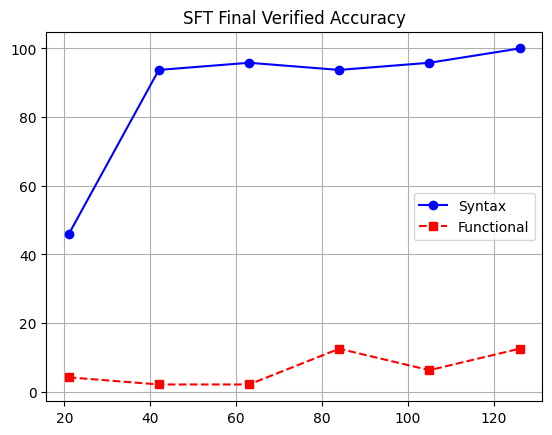

Successfully repaired and overwrote sft_evaluation_results.json!


In [8]:
# Link the datasets already loaded in your Jupyter memory
meta_map = { item["prompt"]: {"cities": item["cities"], "durations": item["durations"]} for item in eval_dataset }

with open("sft_evaluation_results.json", "r") as f:
    results = json.load(f)

new_summary = {}

for step, data in results.items():
    logs = data.get("detailed_logs", [])
    syn_succ = 0; func_succ = 0
    for log in logs:
        prompt = log.get("prompt_used", "")
        code = extract_code(log.get("generated_text", ""))
        meta = meta_map.get(prompt, {"cities": "", "durations": ""})
        
        is_syn, msg, plan = test_code_execution(code)
        
        # 1. NEW: Check function correctly and track boolean
        is_func = False
        if is_syn:
            syn_succ += 1
            if verify_plan(plan, meta["cities"], meta["durations"]):
                func_succ += 1
                is_func = True
                
        # 2. NEW: Overwrite the bad RunPod logs with your actual successful executions!
        log["syntax_passed"] = is_syn
        log["functional_passed"] = is_func
        log["execution_message"] = msg
                
    syn_acc = (syn_succ / len(logs)) * 100
    func_acc = (func_succ / len(logs)) * 100
    
    # 3. NEW: Save the repaired rigorous logs back into the dictionary!
    new_summary[step] = {
        "syntax": syn_acc, 
        "functional": func_acc,
        "detailed_logs": logs
    }
    
    print(f"Step {step} | Syntax: {syn_acc:.2f}% | Functional: {func_acc:.2f}%")

# Save directly back to the ORIGINAL file name to completely overwrite and repair it!
with open("sft_evaluation_results.json", "w") as f:
    json.dump(new_summary, f, indent=4)

steps = sorted([int(k) for k in new_summary.keys()])
plt.plot(steps, [new_summary[str(s)]["syntax"] for s in steps], '-bo', label="Syntax")
plt.plot(steps, [new_summary[str(s)]["functional"] for s in steps], '--rs', label="Functional")
plt.legend(); plt.grid(True); plt.title("SFT Final Verified Accuracy")
plt.savefig("sft_final_graph.png")
plt.show()

print("Successfully repaired and overwrote sft_evaluation_results.json!")
